<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/analysis/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

final_data = pd.read_csv("final_dataset.csv", index_col=0)
final_data.index = pd.to_datetime(final_data.index)

final_data.head()
final_data.info()
final_data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 196 entries, 2005-01-31 to 2021-04-30
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   GENERAL_DAM_OCCUPANCY_RATE  196 non-null    float64
 1   GENERAL_DAM_RESERVED_WATER  196 non-null    float64
 2   precipitation_sum (mm)      196 non-null    float64
 3   temperature_2m_mean (°C)    196 non-null    float64
 4   rain_sum (mm)               196 non-null    float64
 5   snowfall_sum (cm)           196 non-null    float64
dtypes: float64(6)
memory usage: 10.7 KB


,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm),snowfall_sum (cm)
count,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000
mean,64.861690,563.397437,57.812755,14.871435,54.771939,2.191786
std,23.217389,201.703248,41.618465,6.764106,39.166955,5.993851
min,12.230968,106.387097,0.800000,2.767742,0.800000,0.000000
25%,48.431214,420.601786,26.300000,8.441935,25.425000,0.000000
50%,67.276613,584.483871,51.550000,14.537097,50.000000,0.000000
75%,85.827857,745.587500,81.025000,21.352500,78.800000,0.140000
max,98.714839,857.580645,252.400000,26.545161,252.400000,37.170000


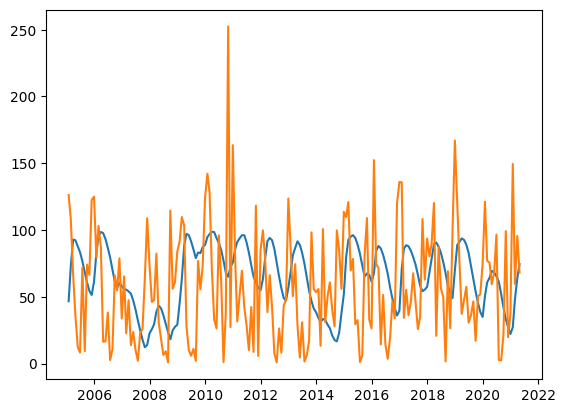

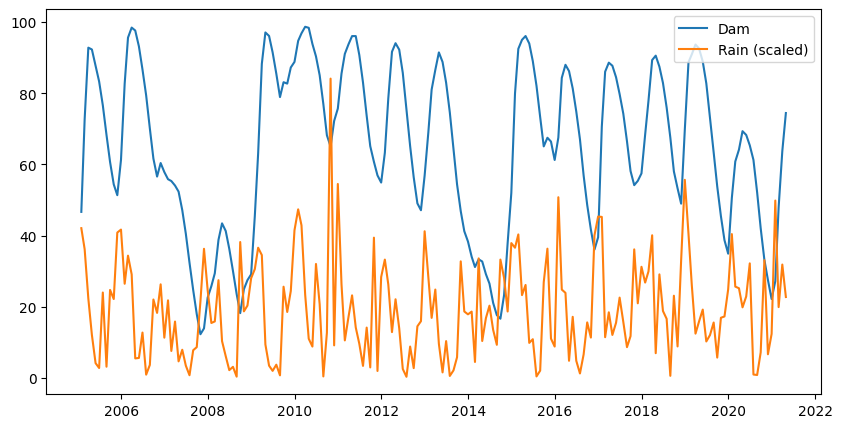

In [6]:
plt.plot(final_data.index, final_data["GENERAL_DAM_OCCUPANCY_RATE"])
plt.plot(final_data.index, final_data["precipitation_sum (mm)"])
plt.show()

plt.figure(figsize=(10,5))

plt.plot(final_data.index, final_data["GENERAL_DAM_OCCUPANCY_RATE"], label="Dam")
plt.plot(final_data.index, final_data["precipitation_sum (mm)"]/3, label="Rain (scaled)")

plt.legend()
plt.show()

Dam occupancy changes gradually over time and shows seasonal patterns, while rainfall fluctuates sharply with irregular spikes. This indicates that short-term rainfall changes do not immediately translate into dam level changes.

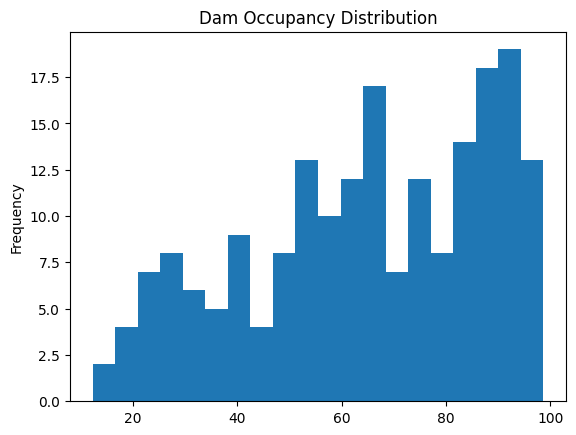

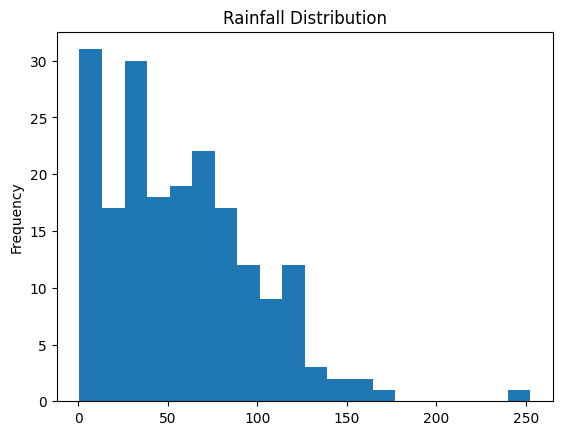

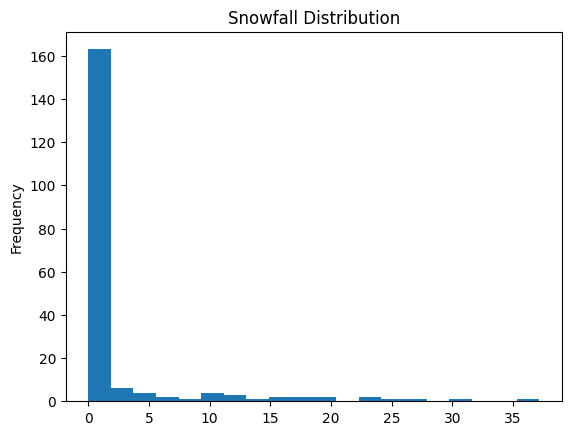

In [13]:
final_data["GENERAL_DAM_OCCUPANCY_RATE"].plot(kind="hist", bins=20)
plt.title("Dam Occupancy Distribution")
plt.show()

final_data["precipitation_sum (mm)"].plot(kind="hist", bins=20)
plt.title("Rainfall Distribution")
plt.show()

final_data["snowfall_sum (cm)"].plot(kind="hist", bins=20)
plt.title("Snowfall Distribution")
plt.show()

Dam occupancy values are mostly concentrated at higher levels (around 60–100%), suggesting that reservoirs are generally kept relatively full.

Rainfall is right-skewed, meaning most observations are low, with occasional extreme high rainfall events.

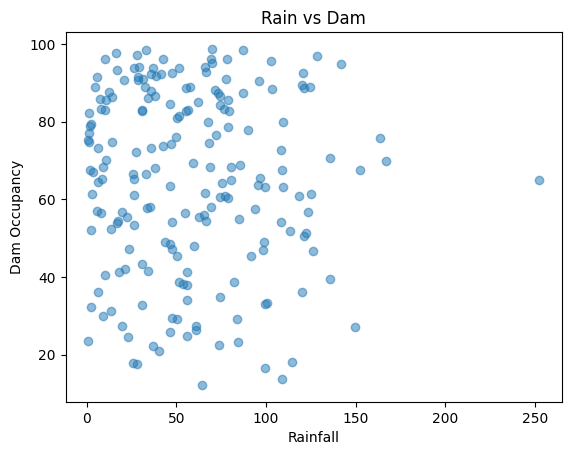

In [8]:
plt.scatter(
    final_data["precipitation_sum (mm)"],
    final_data["GENERAL_DAM_OCCUPANCY_RATE"],
    alpha=0.5
)

plt.xlabel("Rainfall")
plt.ylabel("Dam Occupancy")
plt.title("Rain vs Dam")
plt.show()

The scatter plot does not show a clear relationship between rainfall and dam occupancy. High rainfall values do not consistently correspond to high dam levels.

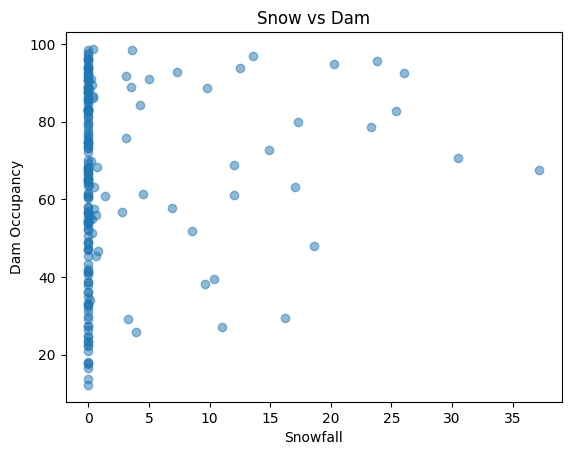

In [11]:
plt.scatter(
    final_data["snowfall_sum (cm)"],
    final_data["GENERAL_DAM_OCCUPANCY_RATE"],
    alpha=0.5
)

plt.xlabel("Snowfall")
plt.ylabel("Dam Occupancy")
plt.title("Snow vs Dam")
plt.show()

The scatter plot shows that snowfall is almost zero for most observations, and when it does occur, a clear relationship with dam occupancy is not seen. This suggests that snowfall is not a strong  predictor of reservoir levels.

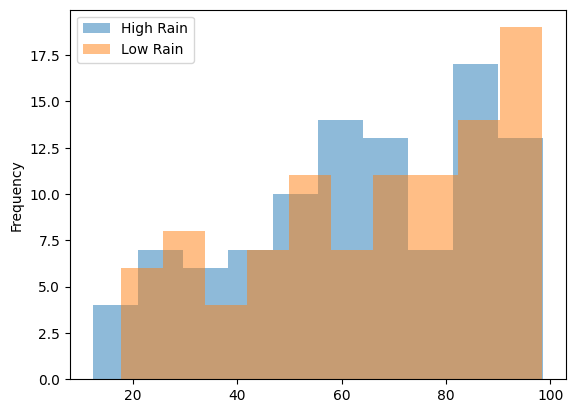

In [10]:
threshold = final_data["precipitation_sum (mm)"].median()

high_rain = final_data[final_data["precipitation_sum (mm)"] > threshold]
low_rain  = final_data[final_data["precipitation_sum (mm)"] <= threshold]

high_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(kind="hist", alpha=0.5, label="High Rain")
low_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(kind="hist", alpha=0.5, label="Low Rain")

plt.legend()
plt.show()

The distributions of dam occupancy under high and low rainfall conditions are very similar, indicating that rainfall level alone may not significantly affect reservoir occupancy.